# Data Preparation

This notebook prepares the divorce dataset for machine learning models by:
1. Loading raw data
2. Preprocessing and cleaning
3. Feature engineering
4. Creating train/test splits
5. Saving processed data for use by all model notebooks

## 1. Imports

In [1]:
import sys
sys.path.append('..')

from src.data_loader import load_raw_data, preprocess_data, create_train_test_split, save_processed_data
from src.feature_engineering import engineer_features, get_feature_names
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 2. Load Raw Data

In [2]:
df = load_raw_data('../data/divorce.csv')
print(f"\nRaw data shape: {df.shape}")
print(f"\nFirst few rows:")
df.head(10)

✓ Loaded 8458 records from ../data/divorce.csv

Raw data shape: (8458, 4)

First few rows:


,District,Area,Year,Number
0,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2019 год,1839.0
1,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2018 год,1588.0
2,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2009 год,1349.0
3,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2011 год,1589.0
4,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2000 год,1006.0
5,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2005 год,1292.0
6,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2002 год,1054.0
7,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2001 год,1047.0
8,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2007 год,1287.0
9,АКМОЛИНСКАЯ ОБЛАСТЬ,городская местность,2003 год,1177.0


In [3]:
# Data info
print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8458 entries, 0 to 8457
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   District  8458 non-null   object 
 1   Area      8458 non-null   object 
 2   Year      8458 non-null   object 
 3   Number    8458 non-null   float64
dtypes: float64(1), object(3)
memory usage: 264.4+ KB


## 3. Preprocess Data

In [4]:
df_clean = preprocess_data(df)
print(f"\nAfter preprocessing: {df_clean.shape}")


Data types:
District     object
Area         object
Year         object
Number      float64
dtype: object
✓ Preprocessed data: (8458, 4)

After preprocessing: (8458, 4)


In [5]:
# Check for missing values
print("\nMissing values:")
print(df_clean.isna().sum())


Missing values:
District    0
Area        0
Year        0
Number      0
dtype: int64


In [6]:
# Basic statistics
print("\nTarget variable (Number) statistics:")
df_clean['Number'].describe()


Target variable (Number) statistics:


count     8458.000000
mean       658.747458
std       3046.351440
min          1.000000
25%         45.250000
50%         94.000000
75%        387.000000
max      59796.000000
Name: Number, dtype: float64

## 4. Feature Engineering

In [7]:
X, y, feature_names = engineer_features(df_clean)
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names: {feature_names}")

Starting feature engineering...

1. Extracting year...
   Year range: 2000 - 2023

2. Encoding district...
✓ Encoded 239 unique districts

3. Encoding area...
✓ Found area types: ['городская местность' 'сельская местность' 'Всего']
✓ Created 3 area features: ['is_total', 'is_urban', 'is_rural']

4. Combining features...

✓ Feature engineering complete!
  Final feature matrix shape: (8458, 5)
  Features: ['year', 'district', 'is_total', 'is_urban', 'is_rural']
  Target shape: (8458,)

Features shape: (8458, 5)
Target shape: (8458,)

Feature names: ['year', 'district', 'is_total', 'is_urban', 'is_rural']


In [8]:
# Preview features
print("\nFeature matrix preview:")
X.head(10)


Feature matrix preview:


,year,district,is_total,is_urban,is_rural
0,2019,7,False,True,False
1,2018,7,False,True,False
2,2009,7,False,True,False
3,2011,7,False,True,False
4,2000,7,False,True,False
5,2005,7,False,True,False
6,2002,7,False,True,False
7,2001,7,False,True,False
8,2007,7,False,True,False
9,2003,7,False,True,False


## 5. Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = create_train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain target distribution:")
print(y_train.describe())
print(f"\nTest target distribution:")
print(y_test.describe())

✓ Train set: 6766 samples
✓ Test set: 1692 samples

Train set: (6766, 5)
Test set: (1692, 5)

Train target distribution:
count     6766.000000
mean       672.896394
std       3179.925766
min          1.000000
25%         46.000000
50%         95.000000
75%        376.750000
max      59796.000000
Name: Number, dtype: float64

Test target distribution:
count     1692.000000
mean       602.168440
std       2440.197958
min          1.000000
25%         44.000000
50%         90.000000
75%        417.500000
max      44862.000000
Name: Number, dtype: float64


## 6. Save Processed Data

In [10]:
save_processed_data(X_train, X_test, y_train, y_test, feature_names)
print("\n✓ Processed data saved to ../data/processed/")

✓ Saved processed data to data/processed/
  - X_train.csv, X_test.csv
  - y_train.csv, y_test.csv
  - feature_names.json
  - split_info.json

✓ Processed data saved to ../data/processed/


## 7. Data Visualization (Optional)

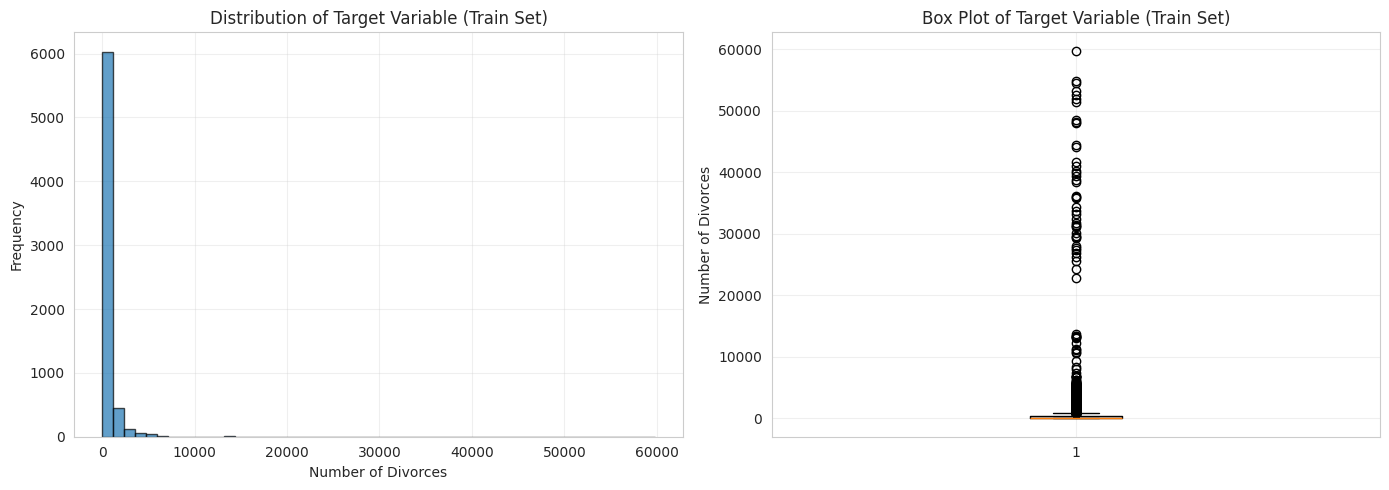

In [11]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y_train, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Divorces')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Target Variable (Train Set)')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(y_train)
axes[1].set_ylabel('Number of Divorces')
axes[1].set_title('Box Plot of Target Variable (Train Set)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

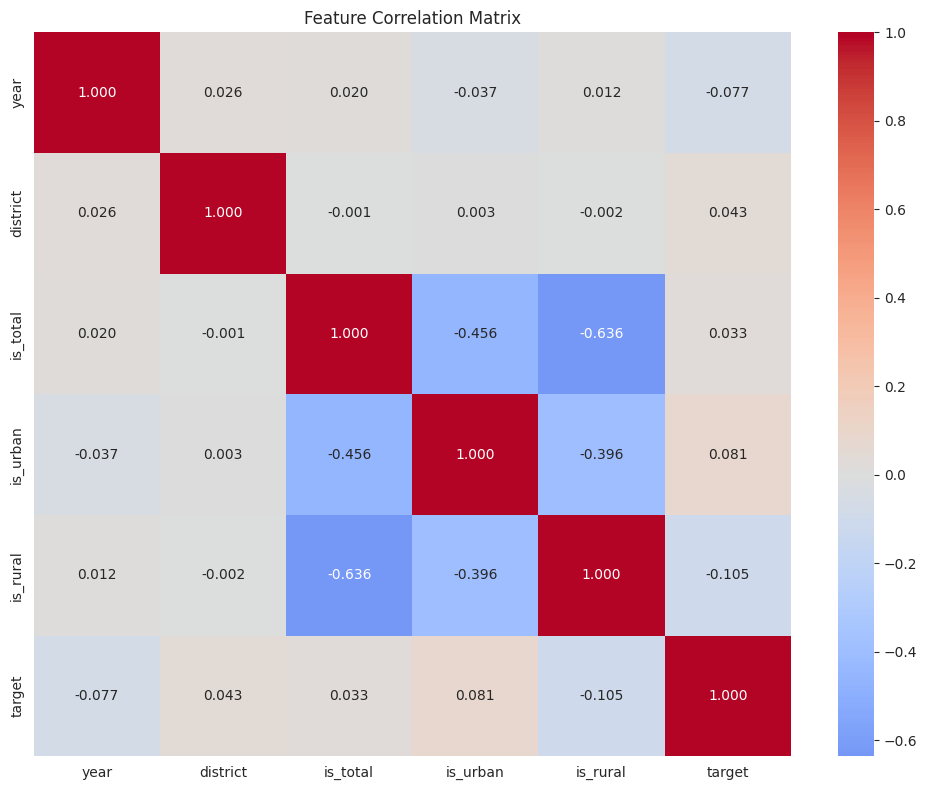

In [12]:
# Feature correlations
plt.figure(figsize=(10, 8))
correlation_data = X_train.copy()
correlation_data['target'] = y_train.values
corr_matrix = correlation_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [13]:
print("\n" + "="*60)
print("DATA PREPARATION COMPLETE!")
print("="*60)
print(f"\nProcessed data saved to: ../data/processed/")
print(f"  - X_train.csv: {X_train.shape}")
print(f"  - X_test.csv: {X_test.shape}")
print(f"  - y_train.csv: {y_train.shape}")
print(f"  - y_test.csv: {y_test.shape}")
print(f"  - feature_names.json")
print(f"  - split_info.json")
print(f"\nYou can now run any of the model notebooks (01-10)!")
print("="*60)


DATA PREPARATION COMPLETE!

Processed data saved to: ../data/processed/
  - X_train.csv: (6766, 5)
  - X_test.csv: (1692, 5)
  - y_train.csv: (6766,)
  - y_test.csv: (1692,)
  - feature_names.json
  - split_info.json

You can now run any of the model notebooks (01-10)!
